# Similarities between countries: clusters

In this notebook, we select the important questions (those we include in our quiz) and compute the similarities between countries to then map those as bubbles.

### Preprocessing

In [34]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import json

In [35]:

project_root = Path.cwd().parent.parent

df = pd.read_csv('../../data/handwritten_answers.csv')

print("Loaded", df.shape[0], "rows and", df.shape[1], "columns")


Loaded 44 rows and 5 columns


In [36]:
# drop all rows where overall_question is "Demographic"
qmeta = df[df['overall_question'] != 'Demographic']

# extract question ids to keep
keep_qs = qmeta['index'].tolist()

print("Keeping", len(keep_qs), "questions:", keep_qs[:10], "…")


Keeping 38 questions: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q29', 'Q37', 'Q41', 'Q59'] …


In [ ]:
project_root = Path.cwd().parent.parent
data_path    = project_root / 'data' / 'subset_df_clean.csv'
df           = pd.read_csv(data_path)


# subset to just country + those questions, drop respondents with all missing answers
# replace 'B_COUNTRY_ALPHA' with column holding country code
cols    = ['B_COUNTRY_ALPHA'] + keep_qs
df_sub  = df[cols].dropna(subset=keep_qs, how='all')

# compute per‐country means
country_means = (
    df_sub
    .groupby('B_COUNTRY_ALPHA')[keep_qs]
    .mean()
    .reset_index()
)

# build feature matrix and list of countries
countries = country_means['B_COUNTRY_ALPHA'].tolist()
X         = country_means[keep_qs].values  # shape (n_countries, n_questions)

# compute pairwise distances: use euclidian
D = pairwise_distances(X, metric='euclidean')


# embed into 2D with t-SNE on the precomputed distance matrix
tsne = TSNE(
    n_components=2,
    metric='precomputed', 
    init='random',         
    random_state=42,
    perplexity=5           
)
emb = tsne.fit_transform(D)


# export JSON for the front-end
out = [{'country': c, 'x': float(x), 'y': float(y)} for c,(x,y) in zip(countries, emb)]
with open(project_root / 'data' / 'country_embeddings.json', 'w') as f:
    json.dump(out, f, indent=2)

print("✅ country_embeddings.json written with", len(out), "entries")


✅ country_embeddings.json written with 66 entries


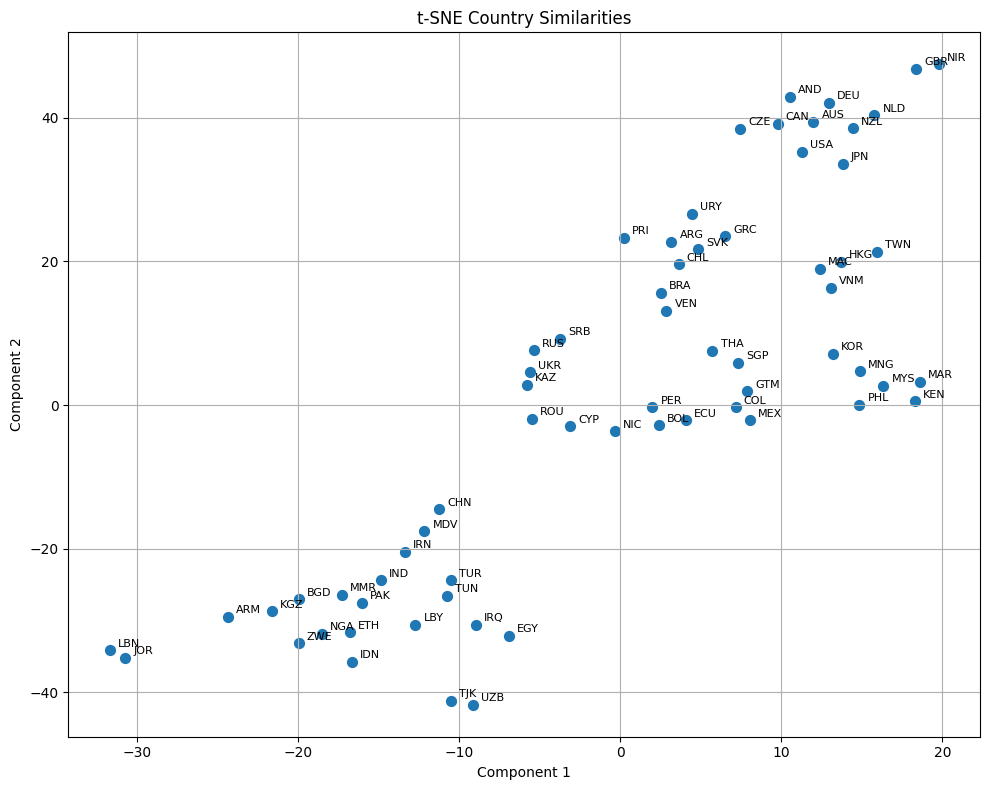

In [ ]:
import json
import matplotlib.pyplot as plt

# load the JSON of embeddings
with open('../../data/country_embeddings.json') as f:
    nodes = json.load(f)

# extract coordinates and labels
xs = [node['x'] for node in nodes]
ys = [node['y'] for node in nodes]
labels = [node['country'] for node in nodes]

# create scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(xs, ys, s=50)

# annotate each point with its country code
for x, y, label in zip(xs, ys, labels):
    plt.text(x + 0.5, y + 0.5, label, fontsize=8)

# check it looks normal
plt.title('t-SNE Country Similarities')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()


# Similarities between individuals: clusters

In [ ]:
# keep only columns with relevant information
extra_cols = ['B_COUNTRY_ALPHA', 'Q262', 'Q260', 'Q289', 'Q275', 'Q287']
cols_to_keep = keep_qs + extra_cols
df_sub = df[cols_to_keep].copy()
mapped = pd.read_csv('../../data/Q290_with_category.csv')  # same row order
df_sub['mapped_category'] = mapped['mapped_category']

# only keep individuals who answered all questions with non-negative values
df_sub_int = df_sub.drop(columns=['B_COUNTRY_ALPHA'])  # exclude non-numeric column
mask = (df_sub_int >= 0).all(axis=1)
df_sub = df_sub[mask].reset_index(drop=True)

In [27]:
df_sub

,Q1,Q2,Q3,Q4,Q5,Q6,Q29,Q37,Q41,Q59,...,Q195,Q196,Q197,B_COUNTRY_ALPHA,Q262,Q260,Q289,Q275,Q287,mapped_category
0,1,1,1,3,1,4,3,4,3,2,...,1,2,4,AND,60,2,1,3,3,1.0
1,1,1,1,4,1,4,3,4,2,2,...,1,1,4,AND,47,1,1,7,2,1.0
2,1,2,2,2,3,3,3,4,4,3,...,2,4,4,AND,48,1,1,7,3,1.0
3,1,3,1,4,1,3,2,1,1,2,...,1,4,4,AND,51,2,1,1,4,1.0
4,1,2,1,4,1,2,4,5,5,2,...,5,1,4,AND,33,2,1,1,4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54243,1,3,1,1,1,2,1,2,1,1,...,1,4,4,ZWE,43,2,1,1,3,2.0
54244,1,1,2,1,1,1,1,5,5,2,...,1,4,4,ZWE,34,1,2,6,2,2.0
54245,1,3,2,2,2,2,3,2,2,2,...,1,4,4,ZWE,22,2,1,2,4,2.0
54246,1,2,2,1,1,1,3,2,2,2,...,1,4,4,ZWE,48,2,1,2,4,2.0


In [42]:
print((df_sub['mapped_category'] == 8.0).sum())

7270


### t-SNE on individuals

In [49]:
X = df_sub[keep_qs].values
tsne = TSNE(n_components=2, random_state=42)
# commenting line below to not run it multiple times (take about 10 minutes)
#coords = tsne.fit_transform(X)

out = [{'id': i+2, 'x': float(x), 'y': float(y)} for i,(x,y) in enumerate(coords)]
with open(project_root / 'data' / 'individuals_embeddings.json', 'w') as f:
    json.dump(out, f, indent=2)

print("✅ individuals_embeddings.json written with", len(out), "entries")

✅ individuals_embeddings.json written with 54248 entries


In [53]:
keep = ['B_COUNTRY_ALPHA', 'Q262', 'Q260', 'Q289', 'Q275', 'Q287', 'mapped_category']
df_sub[keep].to_csv('../../data/individuals_clusters.csv', index=False)

In [ ]:
# select only numeric columns
numeric_df = df_sub.select_dtypes(include='number')

# check for negatives
has_negatives = (numeric_df < 0).any().any()
print("Any negatives?", has_negatives)

Any negatives? False


In [55]:
df = pd.read_csv('../../data/individuals_clusters.csv')
print(df['B_COUNTRY_ALPHA'].unique())
print(df.shape)

['AND' 'ARG' 'ARM' 'AUS' 'BGD' 'BOL' 'BRA' 'CAN' 'CHL' 'COL' 'CYP' 'CZE'
 'ECU' 'ETH' 'GRC' 'GTM' 'HKG' 'IDN' 'IND' 'IRN' 'KAZ' 'KEN' 'KGZ' 'KOR'
 'LBY' 'MAC' 'MAR' 'MDV' 'MEX' 'MMR' 'MNG' 'MYS' 'NGA' 'NIC' 'NLD' 'PAK'
 'PER' 'PHL' 'PRI' 'ROU' 'RUS' 'SGP' 'SRB' 'SVK' 'THA' 'TUN' 'TWN' 'UKR'
 'URY' 'USA' 'VNM' 'ZWE']
(54248, 7)


In [56]:
print((df['mapped_category'] == 8.0).sum())

7270
